In [2]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib as plt

from datasets import load_dataset

# load dataset
using hugging face dataset and importing it using load_dataset

In [3]:
emotion_dataset = load_dataset('dair-ai/emotion')
emotion_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [4]:
emotion_dataset["train"]

Dataset({
    features: ['text', 'label'],
    num_rows: 16000
})

In [5]:
# load emotion text n label seperate n sore it in variable
train_text = emotion_dataset["train"]['text']
train_label = emotion_dataset["train"]['label']
test_text = emotion_dataset["test"]['text']
test_label = emotion_dataset["test"]['label']


In [6]:
print(train_text)
print(train_label)

Column(['i didnt feel humiliated', 'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake', 'im grabbing a minute to post i feel greedy wrong', 'i am ever feeling nostalgic about the fireplace i will know that it is still on the property', 'i am feeling grouchy', ...])
Column([0, 0, 3, 2, 3, ...])


In [7]:
# now how to get the label name form the label 
# ClassLabel(names=['sadness', 'joy', 'love', 'anger', 'fear', 'surprise'])
# but need only names 

label_name = emotion_dataset["train"].features["label"].names
label_name
# ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

create the dataframe from the dataset

In [8]:
train_label
# Column([0, 0, 3, 2, 3, ...])
# now do mapping to label_name 

Column([0, 0, 3, 2, 3, ...])

In [9]:
for i in train_label:
    print(label_name[i])
    
# sadness sadness anger love anger sadness surprise  fear joy love sadness 

sadness
sadness
anger
love
anger
sadness
surprise
fear
joy
love
sadness
joy
anger
sadness
joy
joy
sadness
sadness
sadness
fear
anger
fear
joy
joy
anger
sadness
sadness
sadness
anger
joy
joy
fear
surprise
anger
joy
joy
joy
joy
anger
joy
joy
joy
joy
joy
sadness
sadness
joy
love
joy
anger
joy
sadness
anger
fear
joy
sadness
sadness
surprise
joy
joy
joy
love
fear
fear
surprise
anger
anger
sadness
love
joy
sadness
sadness
joy
sadness
sadness
sadness
joy
joy
joy
anger
sadness
anger
anger
anger
joy
joy
joy
joy
sadness
fear
love
anger
sadness
anger
love
sadness
joy
joy
sadness
anger
love
joy
joy
joy
sadness
joy
joy
joy
joy
sadness
joy
joy
love
sadness
sadness
joy
joy
sadness
joy
joy
fear
fear
fear
sadness
love
joy
joy
love
fear
surprise
joy
joy
joy
joy
anger
fear
joy
anger
love
anger
sadness
joy
sadness
anger
joy
surprise
sadness
anger
anger
sadness
joy
fear
joy
joy
fear
sadness
surprise
surprise
joy
anger
fear
anger
sadness
anger
sadness
fear
sadness
joy
surprise
fear
joy
anger
joy
anger
joy
f

Create dataframe for iported dataset

using pandas n numpy

In [10]:
df_train = pd.DataFrame(
    {"text": train_text, "label": [label_name[i] for i in train_label]}
)
df_test = pd.DataFrame(
    {"text": test_text, "label": [label_name[i] for i in test_label]}
)

In [11]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [12]:
df_test

,text,label
0,im feeling rather rotten so im not very ambiti...,sadness
1,im updating my blog because i feel shitty,sadness
2,i never make her separate from me because i do...,sadness
3,i left with my bouquet of red and yellow tulip...,joy
4,i was feeling a little vain when i did this one,sadness
...,...,...
1995,i just keep feeling like someone is being unki...,anger
1996,im feeling a little cranky negative after this...,anger
1997,i feel that i am useful to my people and that ...,joy
1998,im feeling more comfortable with derby i feel ...,joy


In [13]:
# to check null values
# df_train.isnull().sum()
df_test.isnull().sum()

text     0
label    0
dtype: int64

Exploratory Data Analysis ( EDA )

<Axes: xlabel='label', ylabel='count'>

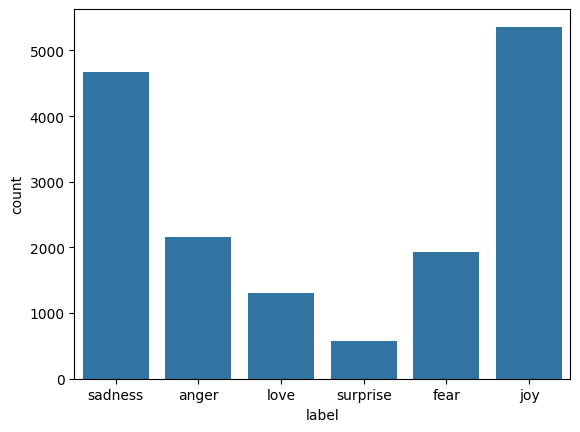

In [14]:
sns.countplot(x='label',data=df_train)

In [15]:
# check in asc ordervice
df_train['label'].value_counts()

label
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

<Axes: xlabel='label', ylabel='count'>

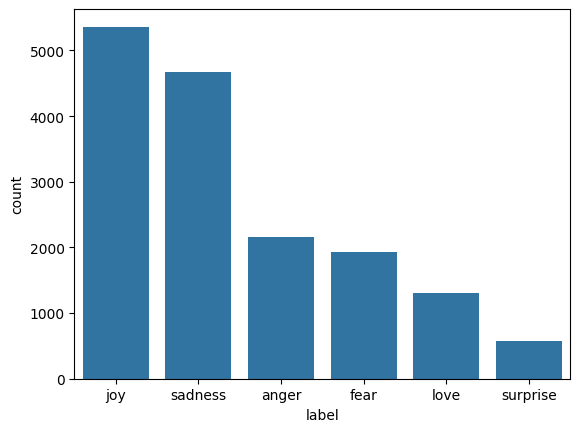

In [16]:
sns.countplot(x='label',data=df_train, order=df_train['label'].value_counts().index)

Data Preprocessing
 
tokenization, pad sentence, and convert labels to numpy array

In [17]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


# now convert the text and label to numerical values using tokanization

example
 nlp = "i feel sad" -> [1,4,40]

 nlp = "i feel grouchy" -> [1,4,30]

 nlp = "i feel humilated" -> [1,4,90]

so here as we see the output depends on last vector value 
unique words are given hiher values

max_words = 10000

# get token
Tokenizer(num_words=max_words,)

but using max words deosnt comes in vocabolary - so its out of vocabolary
so here if the model detect that this word is not in the vocabolary then we can mark it as unkwn then later the word gets some of the vlaue or number weight to it, ( oov_token - < unk >)

we cant we one hot encoding - coulm space inc ( curse of dimentinality )

In [23]:
df_train["text"]

0                                  i didnt feel humiliated
1        i can go from feeling so hopeless to so damned...
2         im grabbing a minute to post i feel greedy wrong
3        i am ever feeling nostalgic about the fireplac...
4                                     i am feeling grouchy
                               ...                        
15995    i just had a very brief time in the beanbag an...
15996    i am now turning and i feel pathetic that i am...
15997                       i feel strong and good overall
15998    i feel like this was such a rude comment and i...
15999    i know a lot but i feel so stupid because i ca...
Name: text, Length: 16000, dtype: object

In [33]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_words = 10000



# get token
tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train["text"])

# eg - "i love nlp" -> ["i":1,"love":5,"nlp":90]
# we provide an id for each word

train_sequence = tokenizer.texts_to_sequences(df_train["text"])
test_sequence = tokenizer.texts_to_sequences(df_test["text"])
# we get only only numbers or tokens -> index
# eg - "i love nlp" -> [1,5,90]

RNN :- 

in every timestamp we give input,

x1,x2,x3,x4 -> inputs ( t=1 )

but now 2nd exmaple 
we have 12 inputes - x1,x2......x12 ( t=2 )

so here rnn struglle for it, so normalize or fill the rmainng input with 0 for 4 input

so max input 23 then reminng all input become 23 - with 0

# this is called paddding sequence

In [ ]:
# padding post - later, pre - at the biggening
# max words ( maxlen ) - 50
# truncating - post , -> 

padded_train_seqence = pad_sequences(train_sequence,maxlen=50,padding='post',truncating='post')
padded_test_seqence = pad_sequences(test_sequence,maxlen=50,padding='post',truncating='post')

padded_train_seqence

#   [[   2,  139,    3, ...,    0,    0,    0],
#    [   2,   40,  101, ...,    0,    0,    0],
#    [  17, 3060,    7, ...,    0,    0,    0],
#    ...,
#    [   2,    3,  327, ...,    0,    0,    0],
#    [   2,    3,   14, ...,    0,    0,    0],
#    [   2,   47,    7, ...,    0,    0,    0]],

array([[   2,  139,    3, ...,    0,    0,    0],
       [   2,   40,  101, ...,    0,    0,    0],
       [  17, 3060,    7, ...,    0,    0,    0],
       ...,
       [   2,    3,  327, ...,    0,    0,    0],
       [   2,    3,   14, ...,    0,    0,    0],
       [   2,   47,    7, ...,    0,    0,    0]],
      shape=(16000, 50), dtype=int32)

In [50]:
# convert label to number same as text using numpy

train_labels = np.array(train_label) 
test_labels = np.array(test_label) 

# train_labels
# array([0, 0, 0, ..., 1, 1, 4], shape=(2000,))

num_clases = len(np.unique(train_labels))
# num_clases - 6
print(f"vocabolary size : {len(tokenizer.word_index)}")
print(f"max sequence length : {padded_train_seqence.shape[1]}")

vocabolary size : 15213
max sequence length : 50


# 5 shared Training utilities 

example - 13500 total samples

sad - 5000               - weight low -

happy - 4500         

joy - 1700

surprise - 800

emo - 900

fear - 600               - weight hight - 

weight = total samples / ( num_class * samples_in_the_class )

used to balance the attention or focus 

eg - 

wt(sad) = 13500 / ( 6 * 5000 )  =  0.45

wt(happy) = 13500 / ( 6 * 4500 ) =  0.50

wt(joy) = 13500 / ( 6 * 1700 ) =  1.32

wt(surprise) = 13500 / ( 6 * 800 ) =  2.81

wt(emo) = 13500 / ( 6 * 900 ) =  2.50

wt(happy) = 13500 / ( 6 * 600 )  =  3.75

In [59]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes = np.unique(train_labels),
    y = train_labels
)

class_weights_dic = dict(enumerate(class_weights))
# enumerate give the index to element

print(train_labels)
class_weights_dic

[0 0 3 ... 1 3 0]


{0: np.float64(0.5715102157451064),
 1: np.float64(0.49732686808404825),
 2: np.float64(2.044989775051125),
 3: np.float64(1.2351397251814111),
 4: np.float64(1.3766993632765445),
 5: np.float64(4.662004662004662)}

 early stopping - so when on epocs loss reduction is reduced a lot or not changing the loss balue then we stop ( reduce proccesing power )

 1 - training - training

 2 - test - unseen data 

 3 - validation - train on few parametrs n check score wch one is best para

 there will be 2 looses - loss and validation loss

 we monitor if noth the loss are changing 

In [65]:
from tensorflow.keras.callbacks import EarlyStopping


early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
# so here we stop epocs when 3 loss has same values and get all the weights n train the model on it